In [88]:
from sklearn.model_selection import cross_val_score, KFold, cross_validate, RepeatedKFold
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold, RFECV, RFE
from sklearn.linear_model import LinearRegression


from ml_enhance import plot_scaled_linreg_result, CorrelationFilter


import matplotlib.pyplot as plt
from sklearn import pipeline
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
import json

In [89]:
def make_pipeline(model, step_name):
    return pipeline.Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("remove_corr", CorrelationFilter(threshold=0.95)),
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", StandardScaler()),
        (step_name, model)
    ])

In [90]:
pl_linear = make_pipeline(LinearRegression(), "predict")

In [117]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_more_qm.csv")

print(df.iloc[8655]["smiles"])
df[df["smiles"] == '[O:1]([O:2][H:4])[H:3]']

[C:1]([C:2](=[O:3])[O:4][C:5]([C:6]([H:18])([H:19])[H:20])([C:7]([H:21])([H:22])[H:23])[C:8]([c:9]1[c:10]([H:26])[c:11]([H:27])[c:12]([H:28])[c:13]([H:29])[c:14]1[H:30])([H:24])[H:25])([H:15])([H:16])[H:17]


,smiles,id,energy,atomization_energy,homo_lumo_gap,ionization_energy,electron_affinity,chemical_potential,molecular_dipole_norm,molecular_quadrupole_principal_invariant_2,molecular_quadrupole_principal_invariant_3,molecular_polarizability_mean,molecular_polarizability_anisotropy,enthalpy,zero_point_energy,radius_of_gyration,molecular_volume,sterimol_L,sterimol_Bmin,sterimol_Bmax,molecular_sasa,solvation_energy_water,solvation_energy_thf,solvation_energy_cyclohexane,solvation_energy_dmso,gibbs_free_energy_300K,entropy_300K,heat_capacity_300K,ir_mode_count_1500,ir_centroid_freq_1500,ir_norm_intensity_1500,ir_mode_count_1500_2750,ir_centroid_freq_1500_2750,ir_norm_intensity_1500_2750,ir_mode_count_2750_4000,ir_centroid_freq_2750_4000,ir_norm_intensity_2750_4000,avg_atomic_dipole_norm,min_atomic_dipole_norm,max_atomic_dipole_norm,...,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,canon_smiles,solubility
8659,[O:1]([O:2][H:4])[H:3],902,-9.054669,0.726228,0.278562,0.607683,-0.030498,-0.288925,0.00155,-22.687318,-35.256462,-5.414069,91.125326,6.594051,15.64872,0.746157,194.817626,4.460858,1.52,2.144231,221.865998,-0.009738,-0.008489,-0.004867,-0.009649,-10.304572,0.056329,0.006251,4.0,637.326543,0.754631,0.0,0.0,0.0,2.0,3539.322304,0.245369,0.18146,0.09233,0.270589,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,OO,0.468342


In [ ]:

df = df.drop("avg_atomic_quadrupole_principal_invariant_3", axis=1)
df = df.drop("min_atomic_quadrupole_principal_invariant_3", axis=1)
df = df.drop("max_atomic_quadrupole_principal_invariant_3", axis=1)
df = df.drop("min_overlap_integral", axis=1)



df = df.drop([1825, 587, 8657, 8169, 8655, 8654])

y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

## Linear Regression: Topology VS. QM + Topology

In [92]:
with open("../data/rdkit_feature_names.json", "r") as f:
    rdkit_feature_list: list = json.load(f)

mask = X.columns.isin(rdkit_feature_list)

In [93]:
X_topo = X.iloc[:, mask]
X_qm = X.iloc[:, ~mask]

In [94]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=15)

In [95]:
scoring = {
    "r2": "r2",
    "MSE": "neg_mean_squared_error"
}

In [96]:
scores_combo = cross_validate(pl_linear, X, y, cv=repeated_cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [97]:
scores_topo = cross_validate(pl_linear, X_topo, y, cv=repeated_cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [98]:

scores_qm = cross_validate(pl_linear, X_qm, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [99]:
print(f"Train R2 scores:\nTopology alone: {scores_topo["train_r2"].mean()}\nQM alone: {scores_qm["train_r2"].mean()}\nCombined: {scores_combo["train_r2"].mean()}")
print("\n")
print(f"Test R2 scores:\nTopology alone: {scores_topo["test_r2"].mean()}\nQM alone: {scores_qm["test_r2"].mean()}\nCombined: {scores_combo["test_r2"].mean()}")

Train R2 scores:
Topology alone: 0.8293807291346671
QM alone: 0.754092103714126
Combined: 0.8447975855468477


Test R2 scores:
Topology alone: 0.8158424630100336
QM alone: 0.7366982303248286
Combined: 0.787874020329646


In [103]:
scores_combo["test_r2"]

array([0.81175558, 0.81509899, 0.82167163, 0.83869318, 0.83939718,
       0.80544035, 0.825834  , 0.83808785, 0.8248135 , 0.81922239,
       0.82195283, 0.84431148, 0.83497701, 0.82360845, 0.06061556,
       0.83128097, 0.8442114 , 0.82498896, 0.81856242, 0.78847141,
       0.68975477, 0.8376881 , 0.80619826, 0.80165606, 0.82855815])

In [104]:
faulty_pl = scores_combo["estimator"][14]
X_trans = faulty_pl[:-1].transform(X)
X_trans_df = pd.DataFrame(
    X_trans,
    columns=faulty_pl[:-1].get_feature_names_out()
)

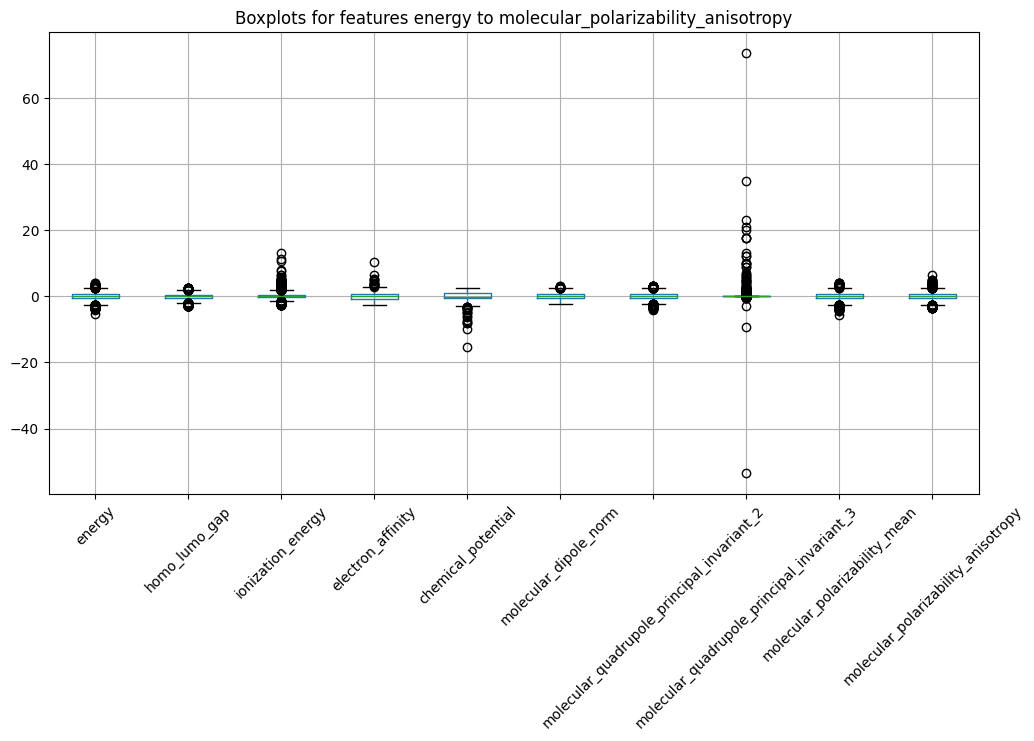

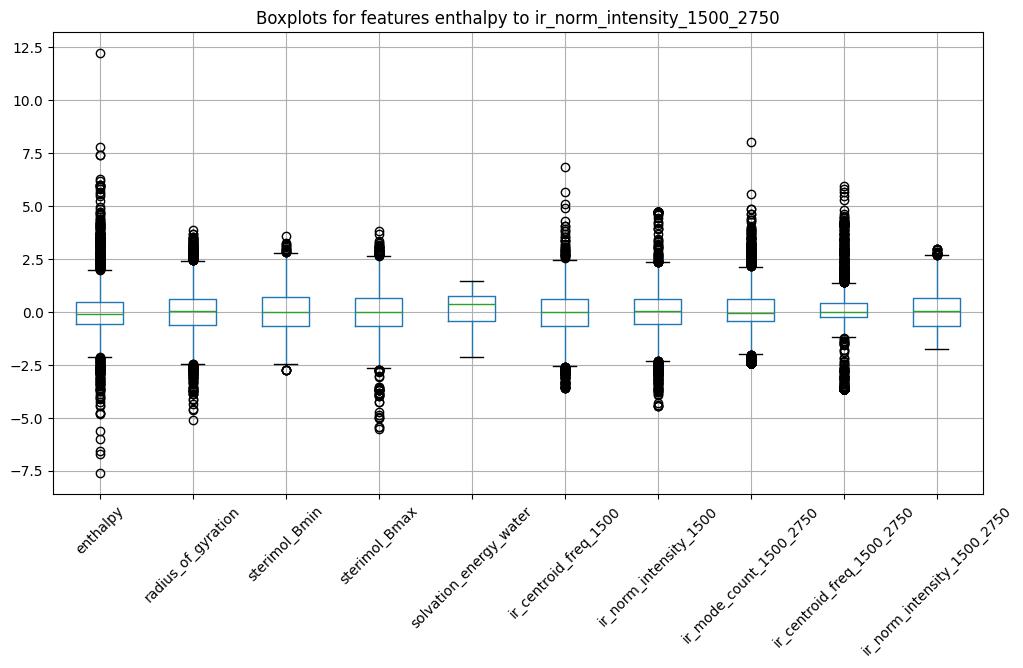

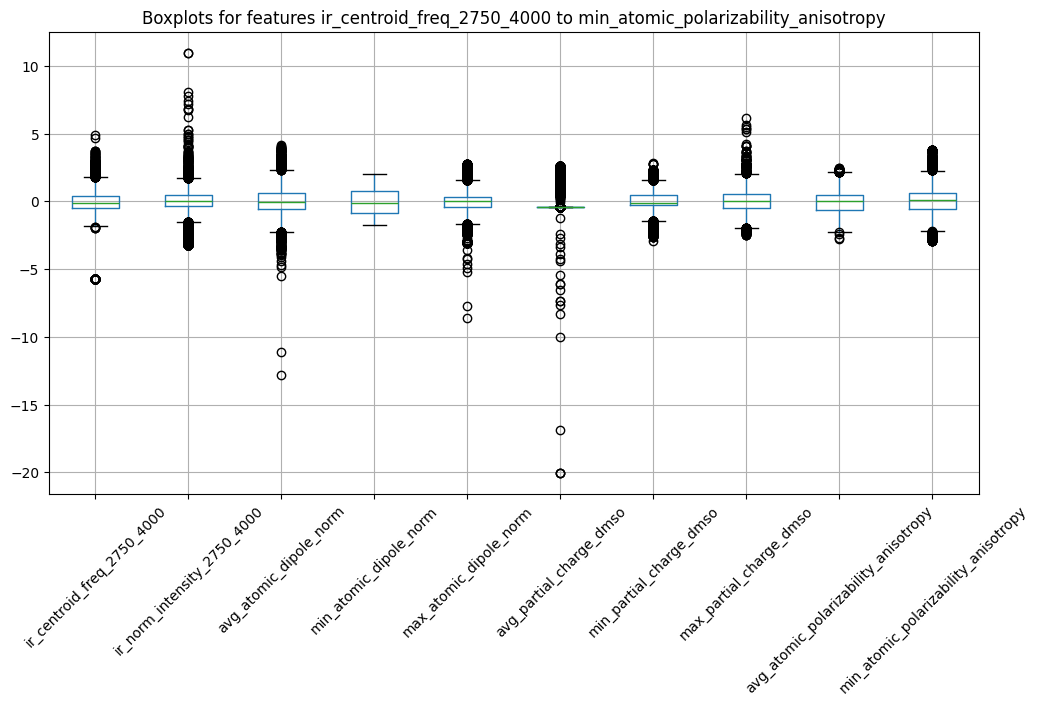

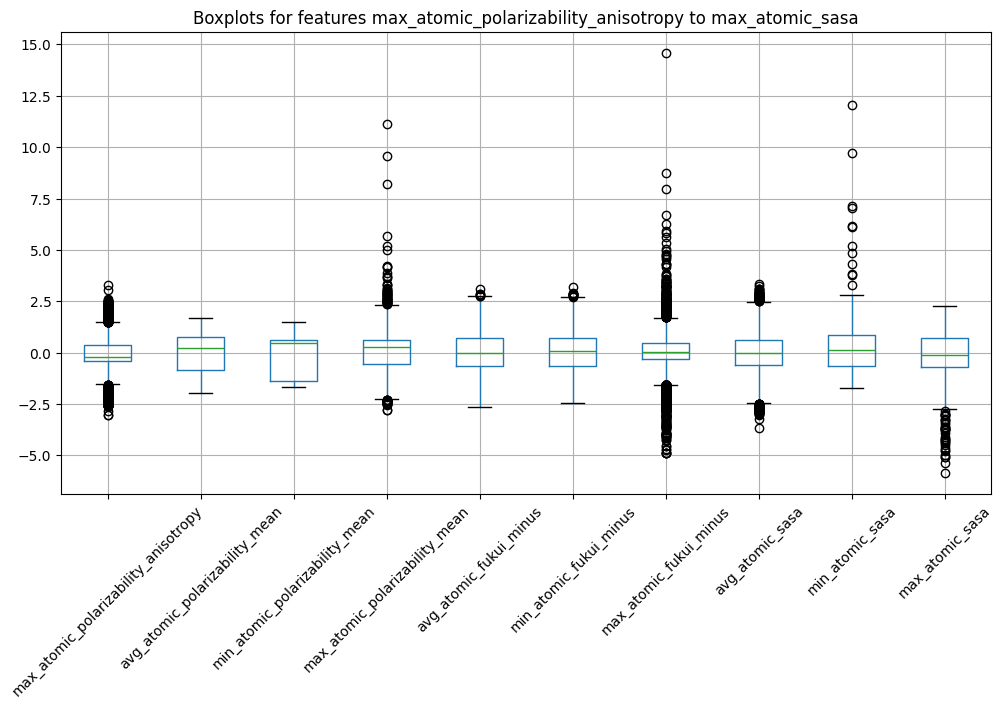

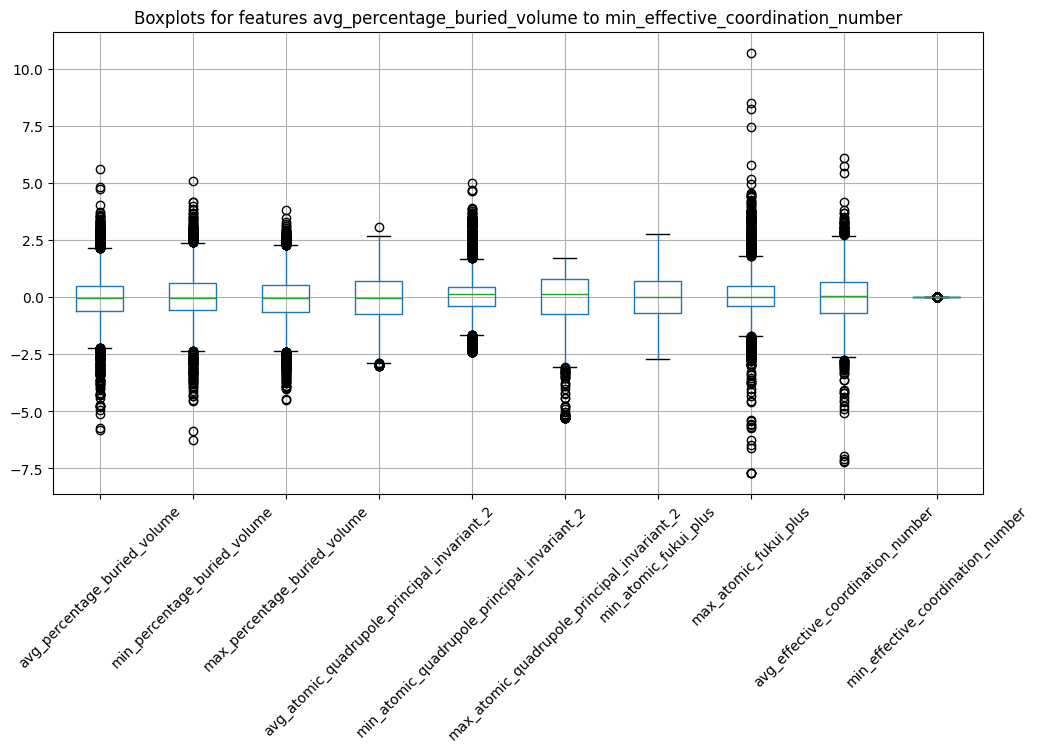

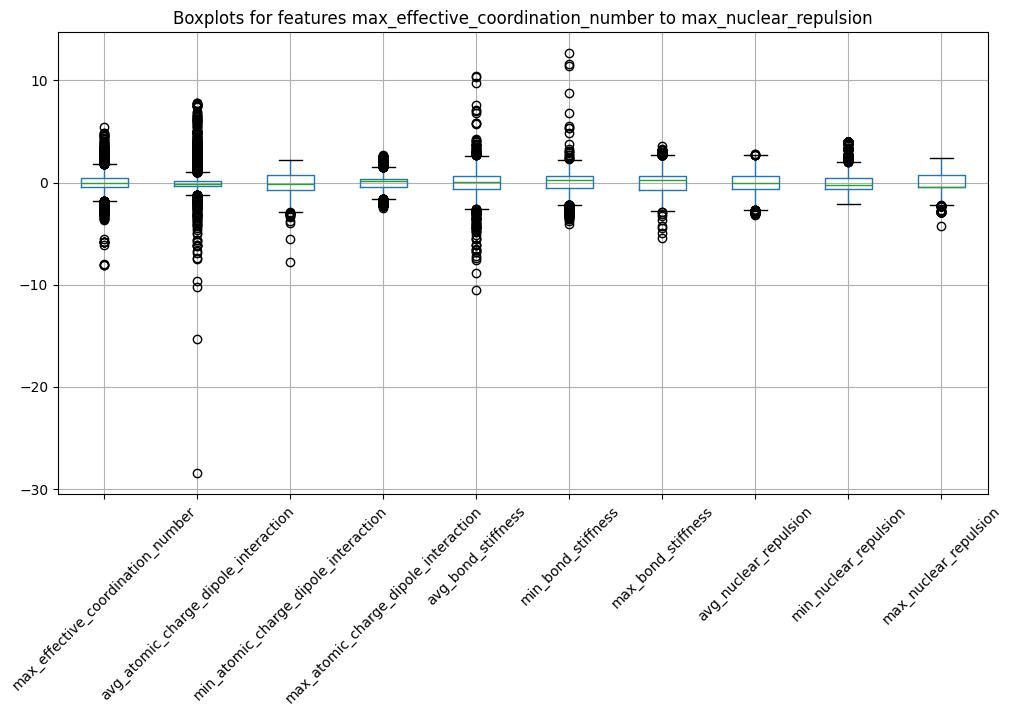

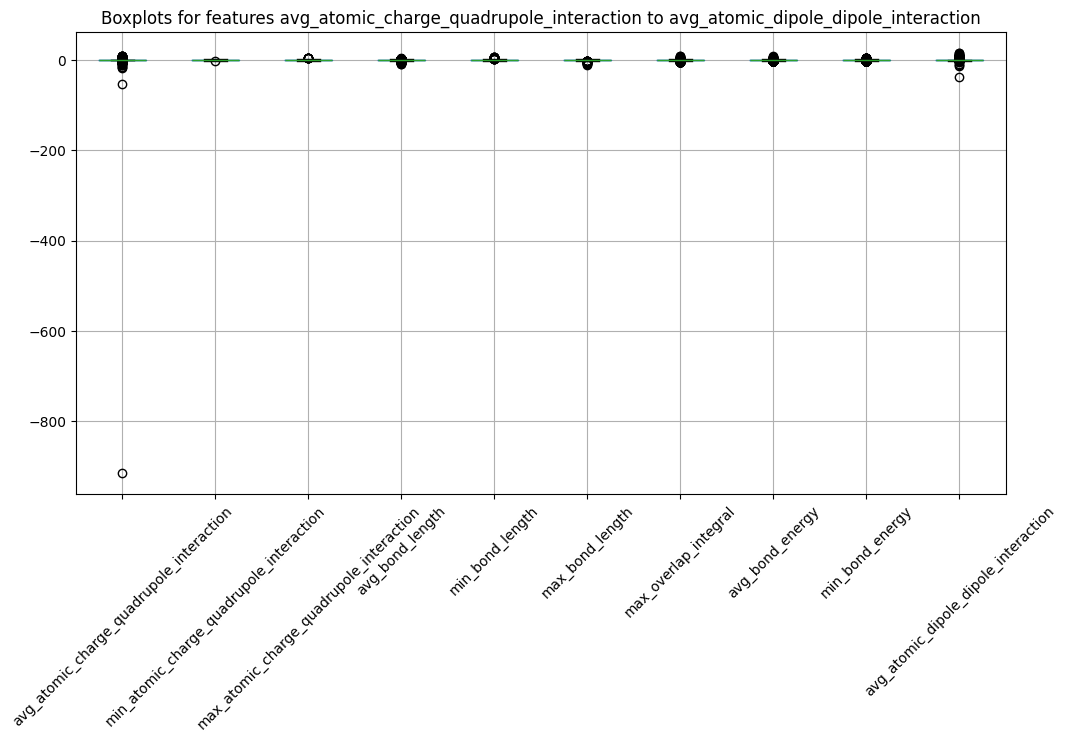

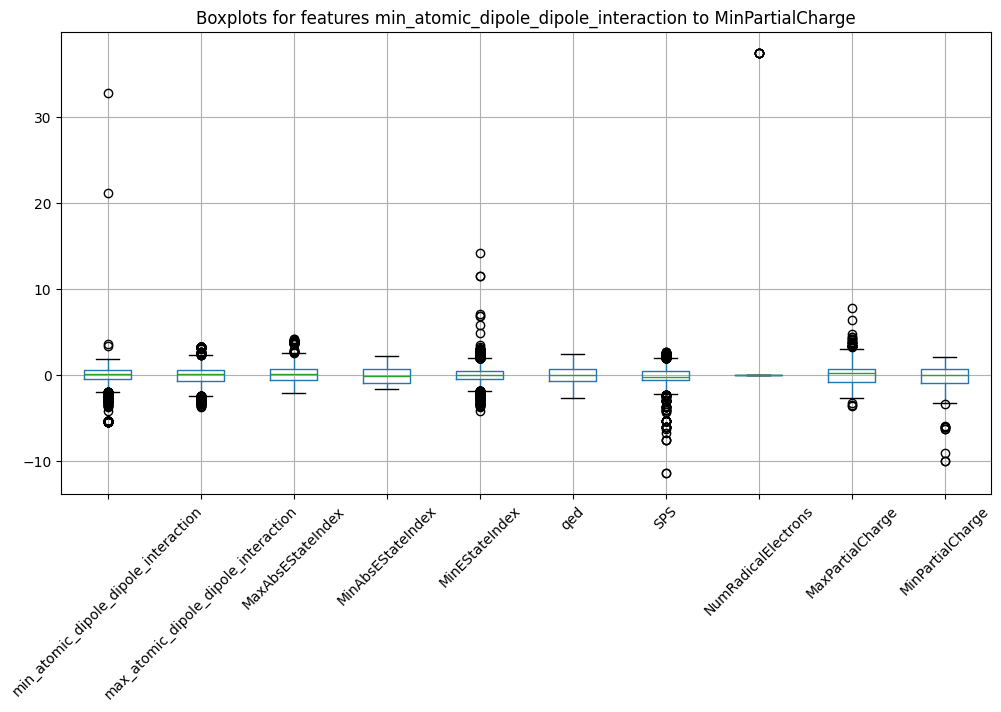

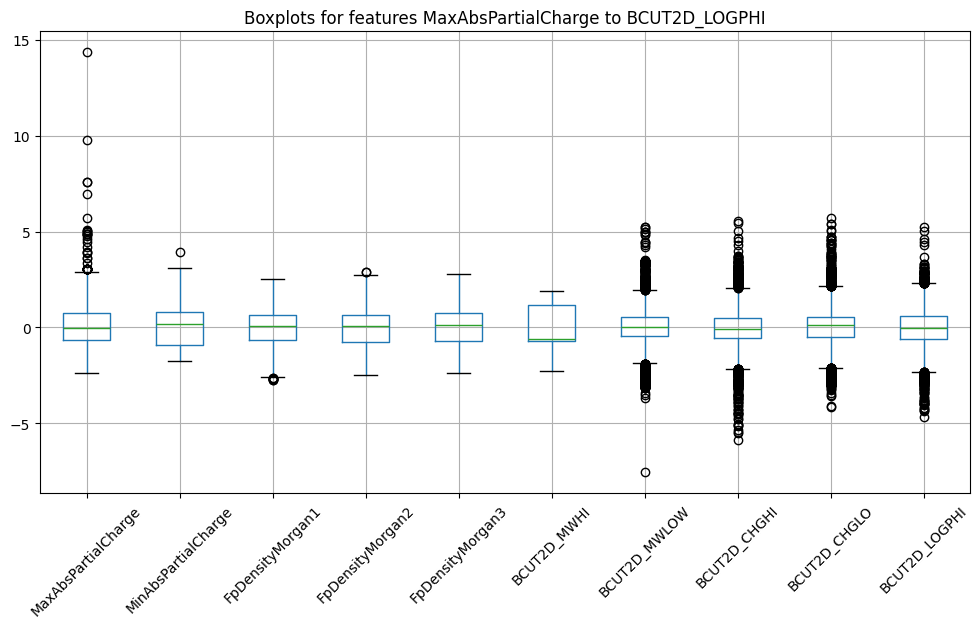

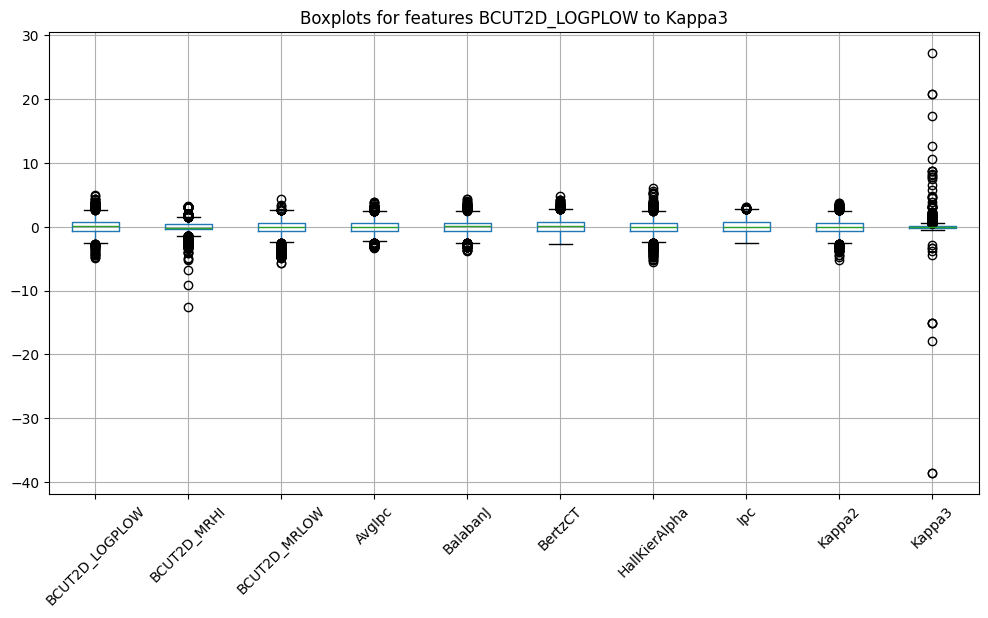

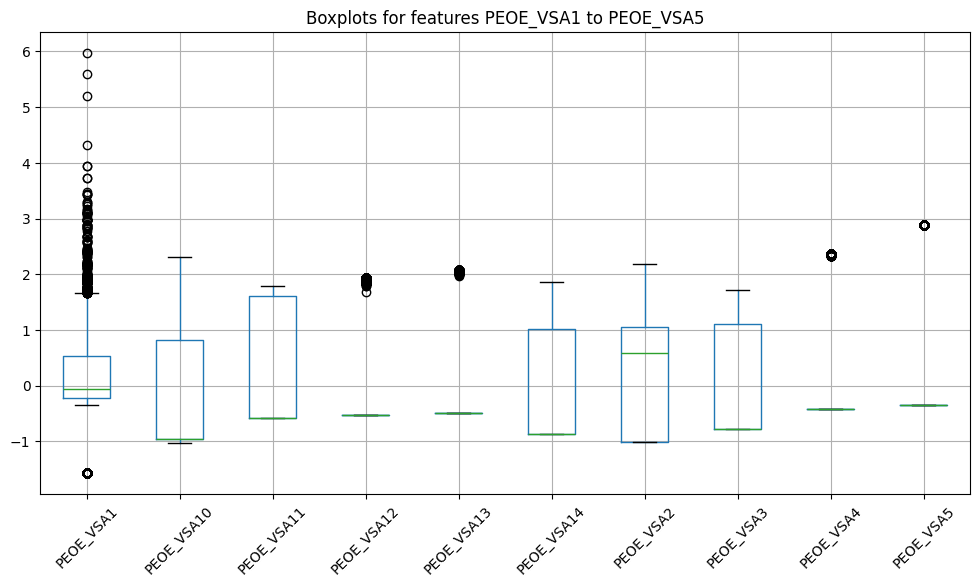

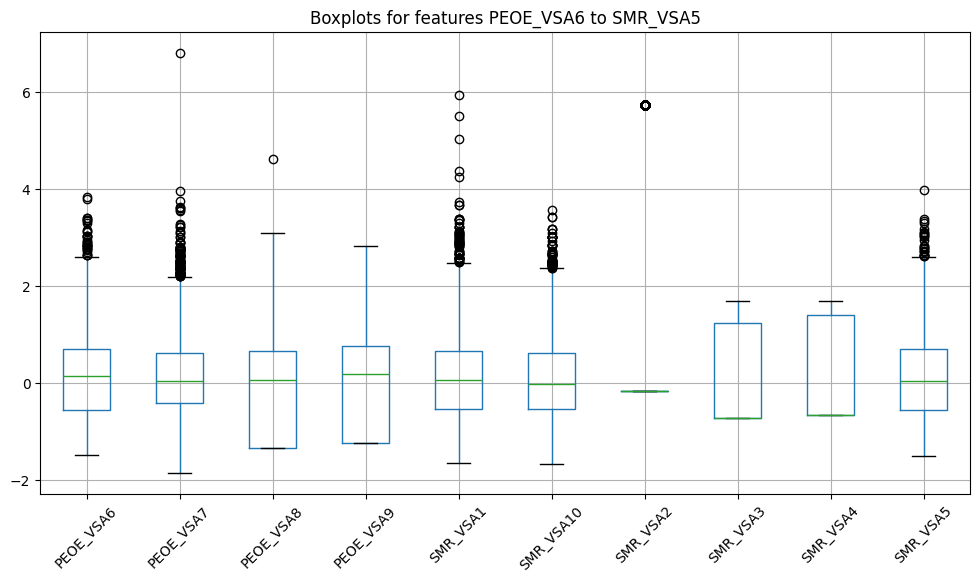

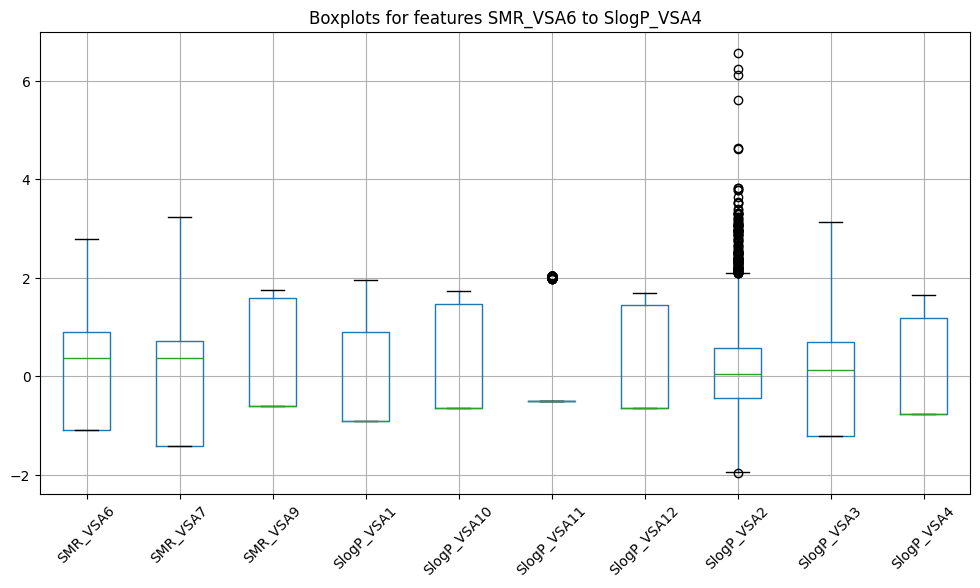

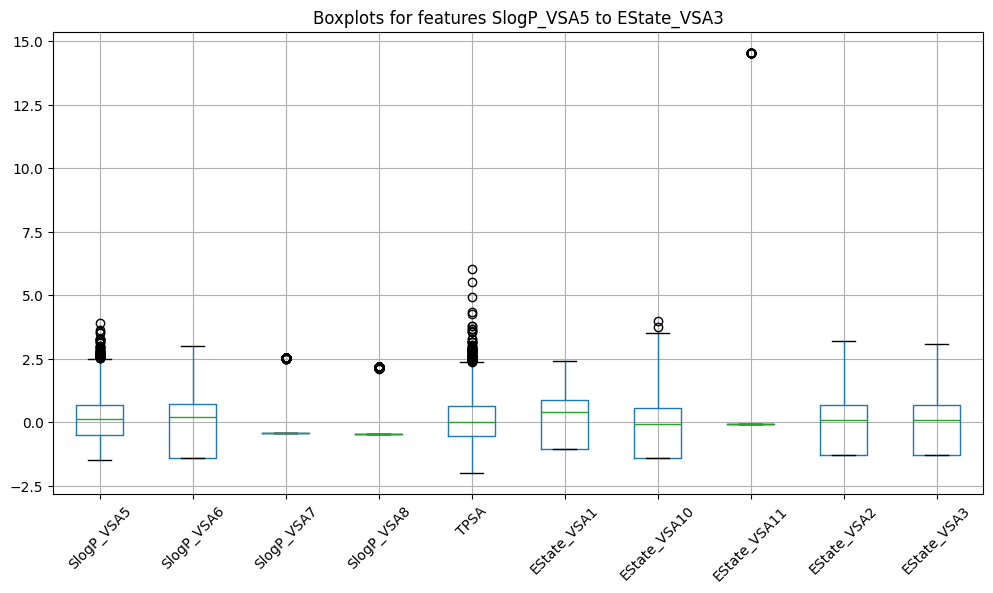

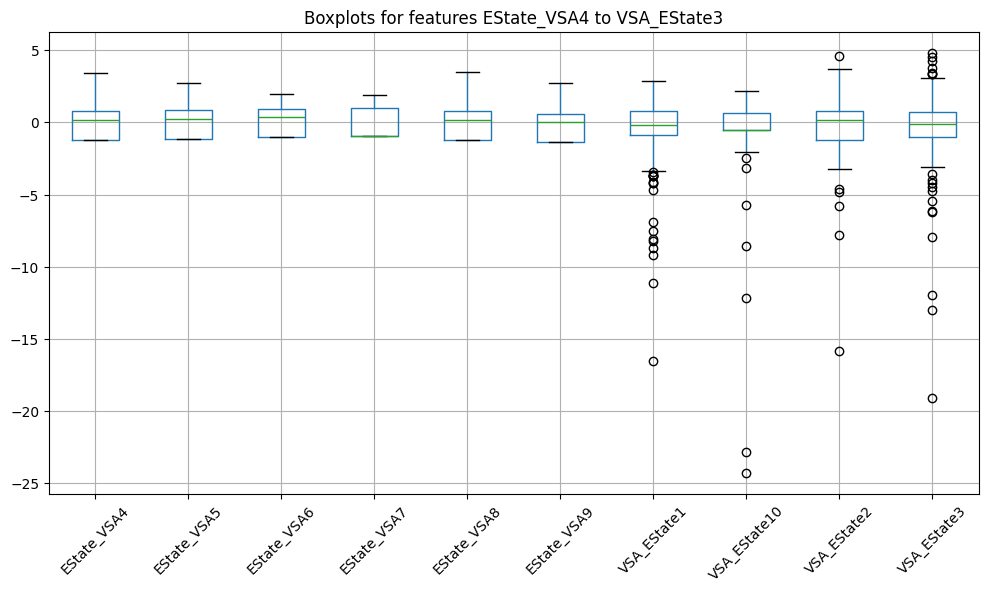

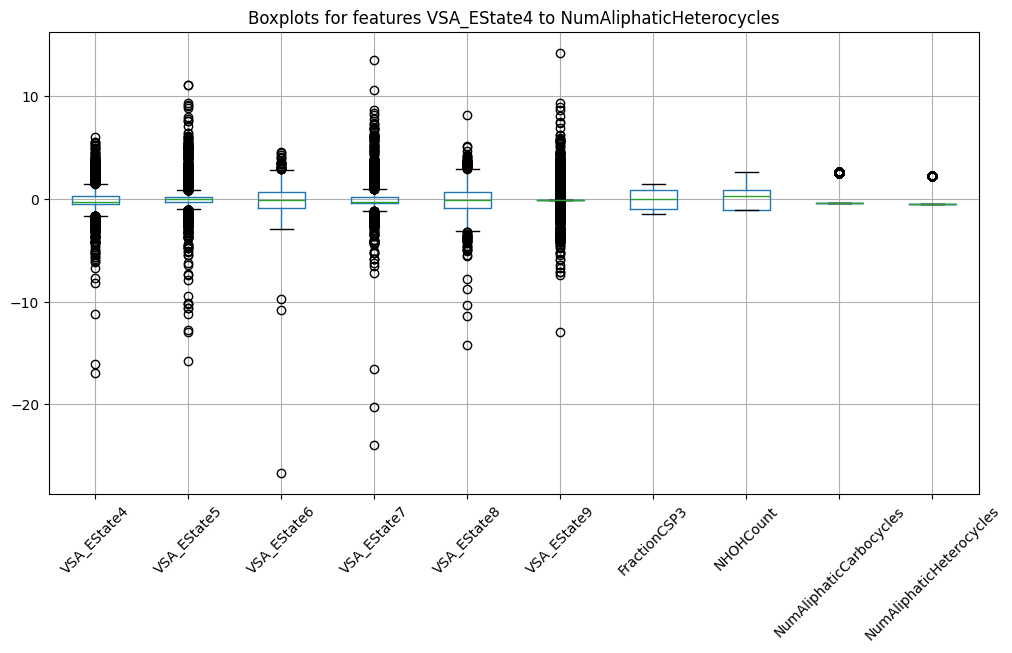

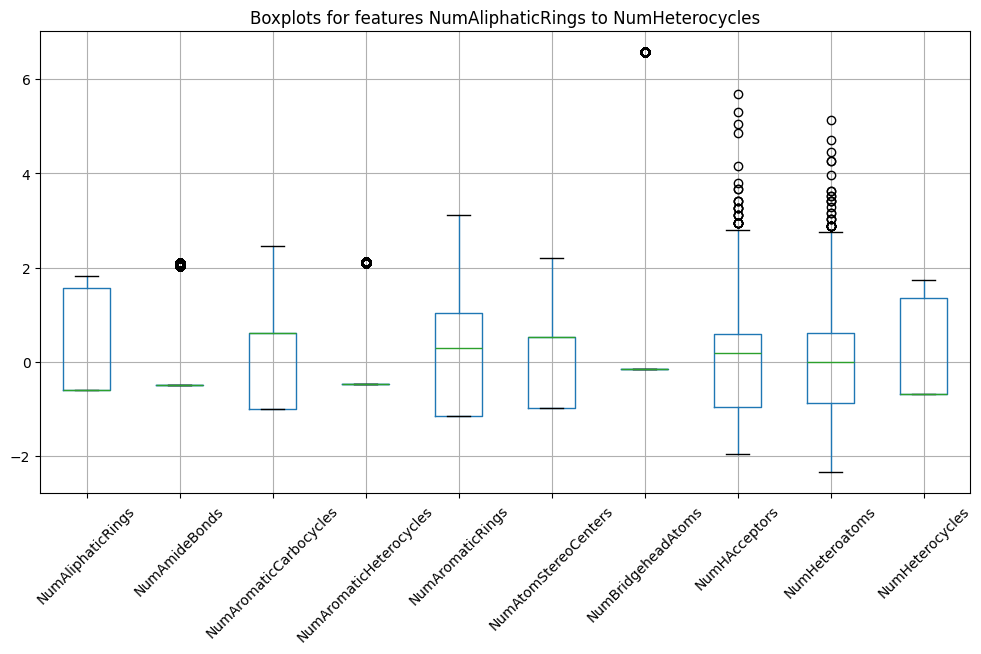

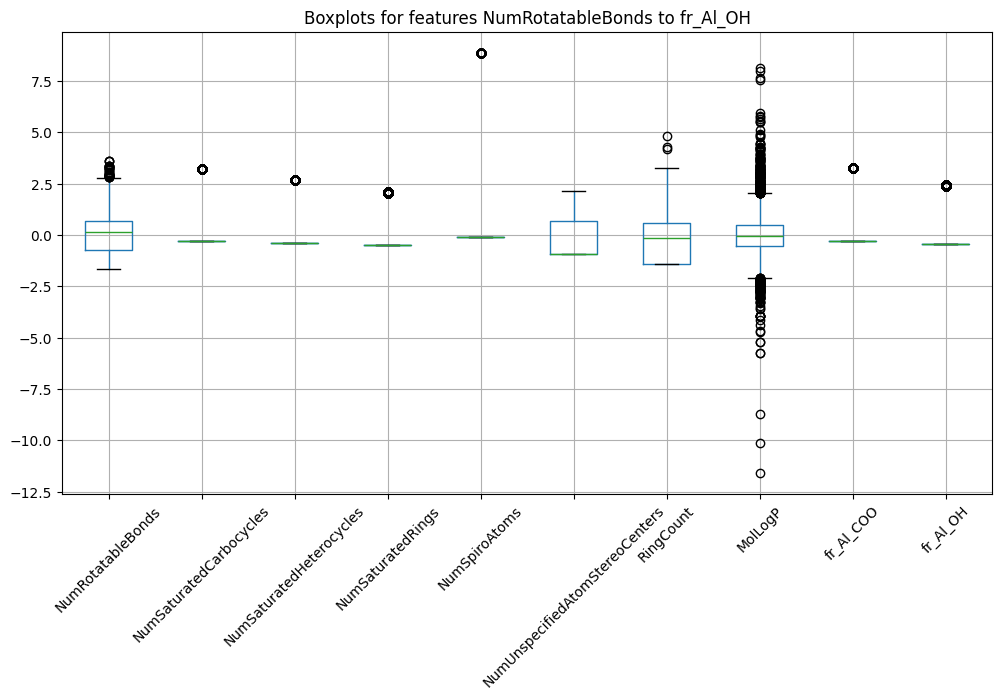

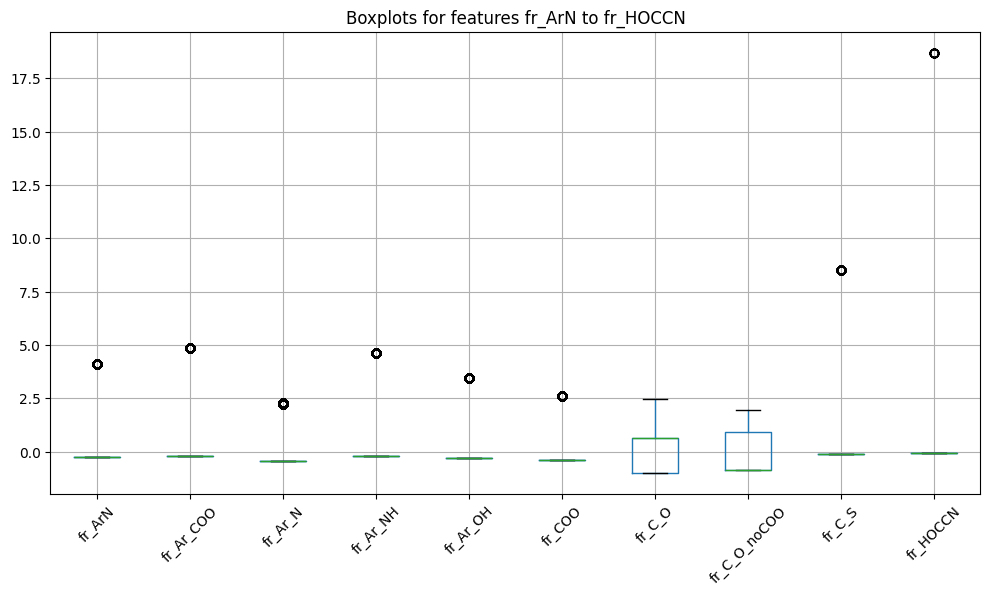

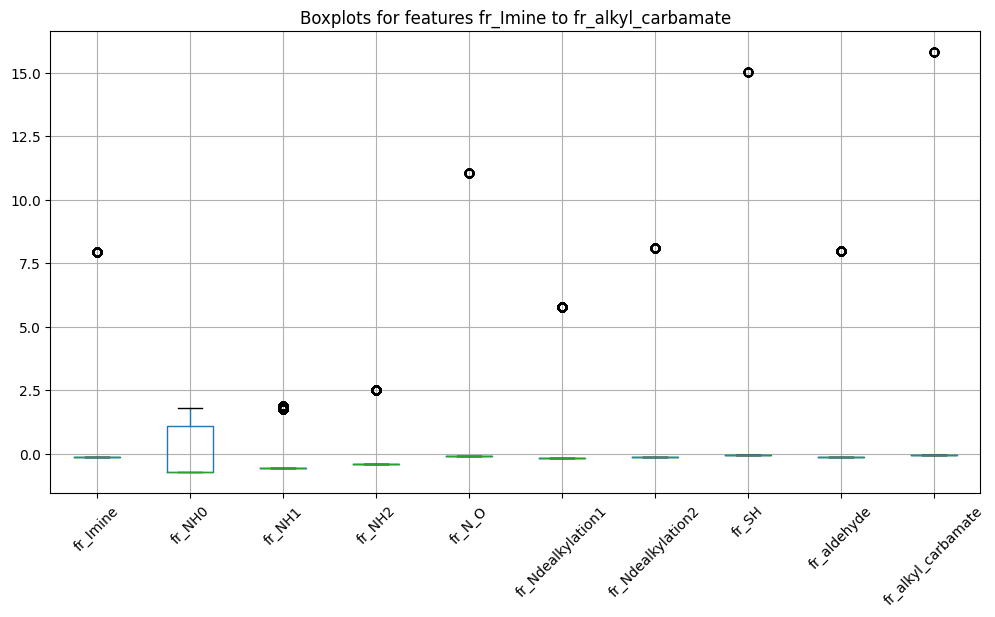

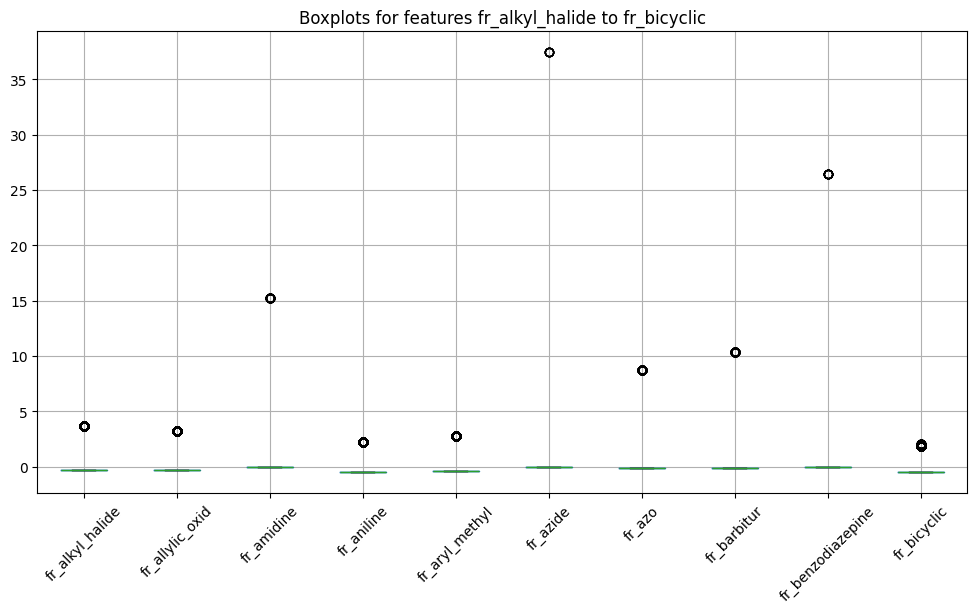

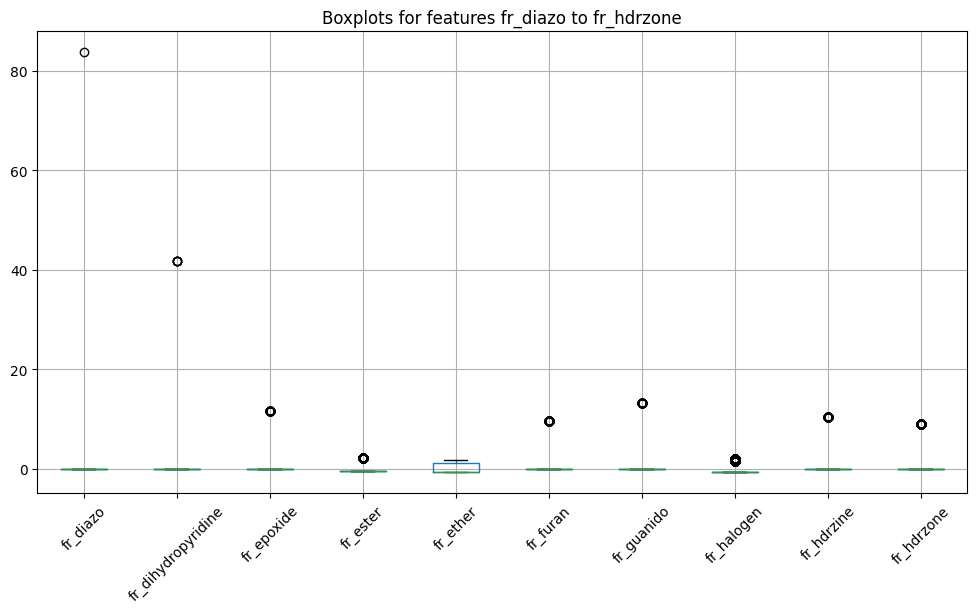

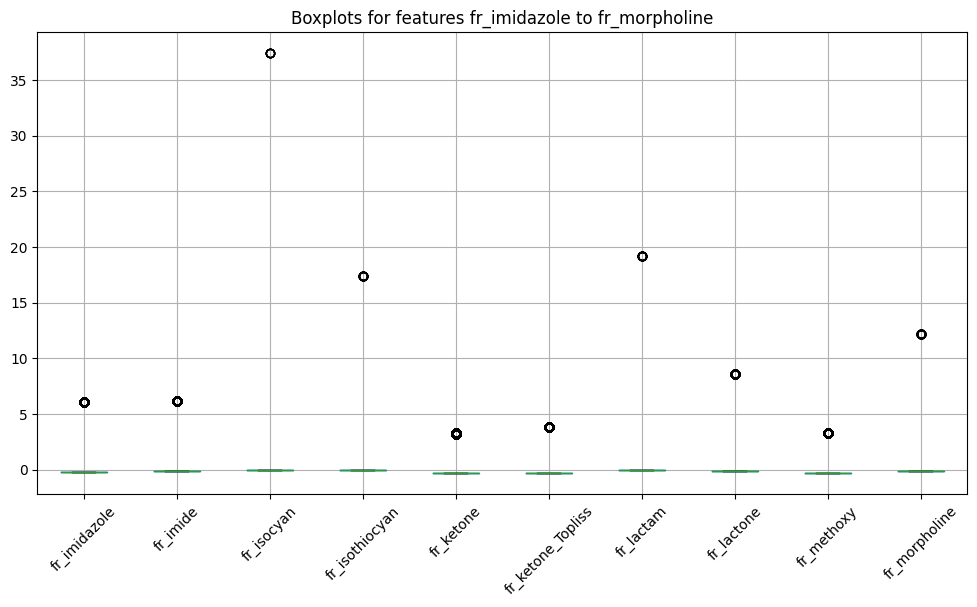

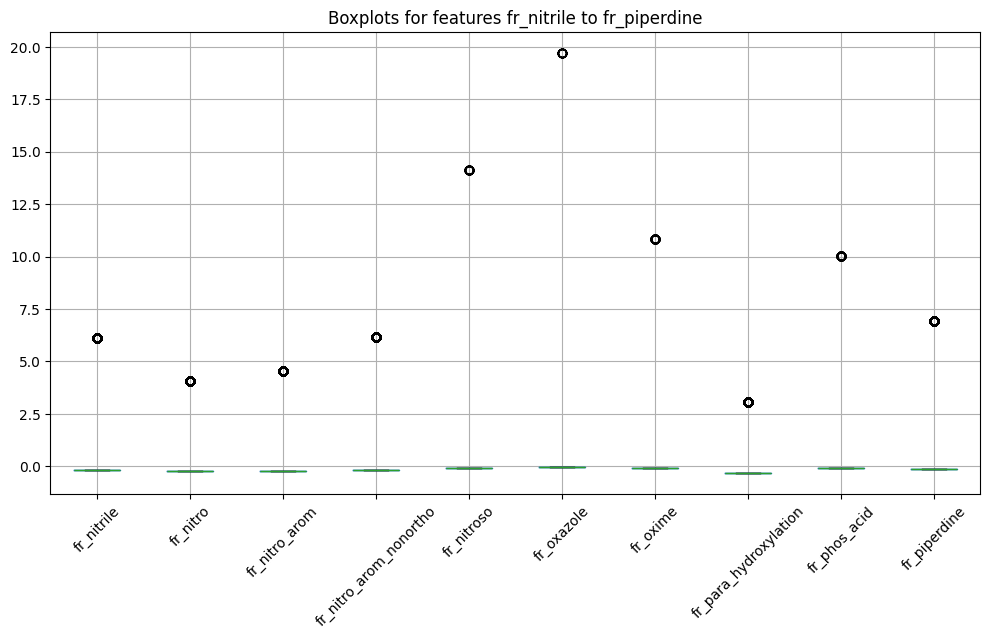

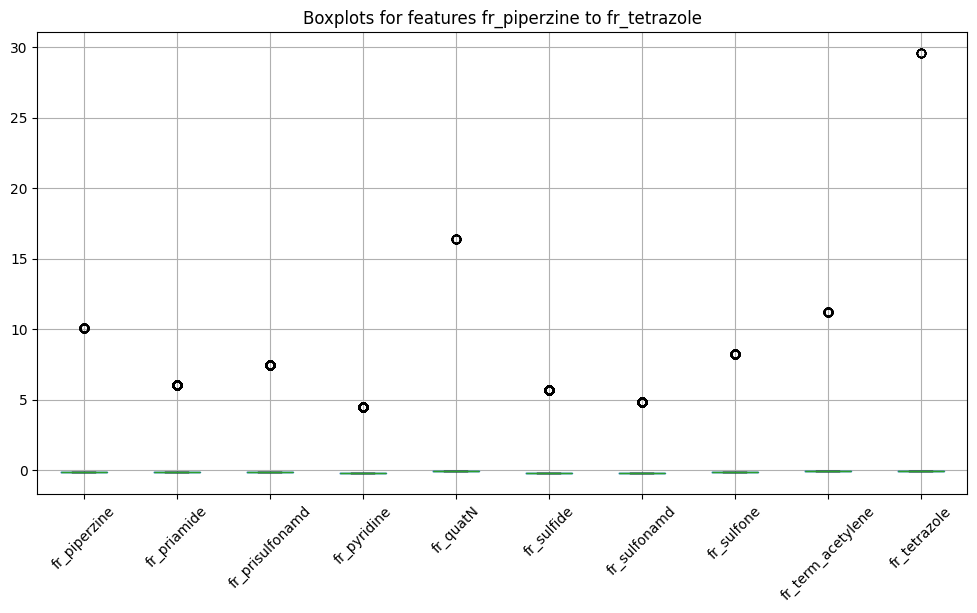

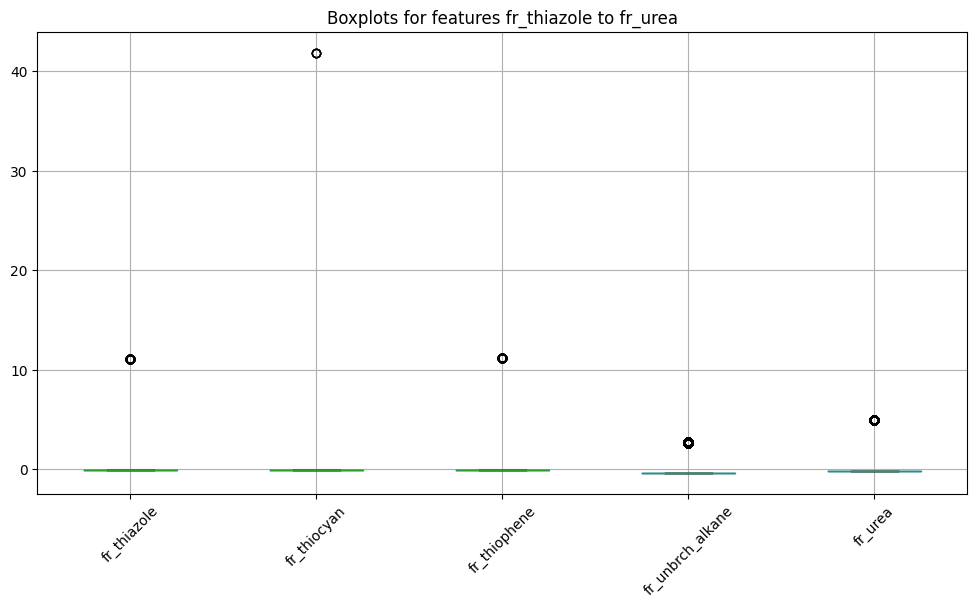

In [105]:
feature_groups = [X_trans_df.columns[i:i+10] for i in range(0, len(X_trans_df.columns), 10)]

for i, group in enumerate(feature_groups, 1):
    plt.figure(figsize=(12,6))
    X_trans_df[group].boxplot()
    plt.title(f'Boxplots for features {group[0]} to {group[-1]}')
    plt.xticks(rotation=45)
    plt.show()

In [106]:
X_trans_df["avg_atomic_charge_quadrupole_interaction"].sort_values()

8654   -914.612918
1308    -52.345749
8168    -16.960592
2330    -15.098529
1319    -14.628681
           ...    
1194      8.778267
537       8.958404
5370      9.151003
3634      9.270974
7357      9.346600
Name: avg_atomic_charge_quadrupole_interaction, Length: 8758, dtype: float64

In [124]:
df["avg_atomic_charge_quadrupole_interaction"].sort_values()

8659   -0.023400
1309   -0.009598
8171   -0.005282
2332   -0.004910
1320   -0.004812
          ...   
1195    0.014237
537     0.016197
5372    0.019731
3636    0.024652
7359    0.132407
Name: avg_atomic_charge_quadrupole_interaction, Length: 8763, dtype: float64

In [128]:
df.iloc[7359]["smiles"]

'[O:1]=[Si:2]=[O:3]'

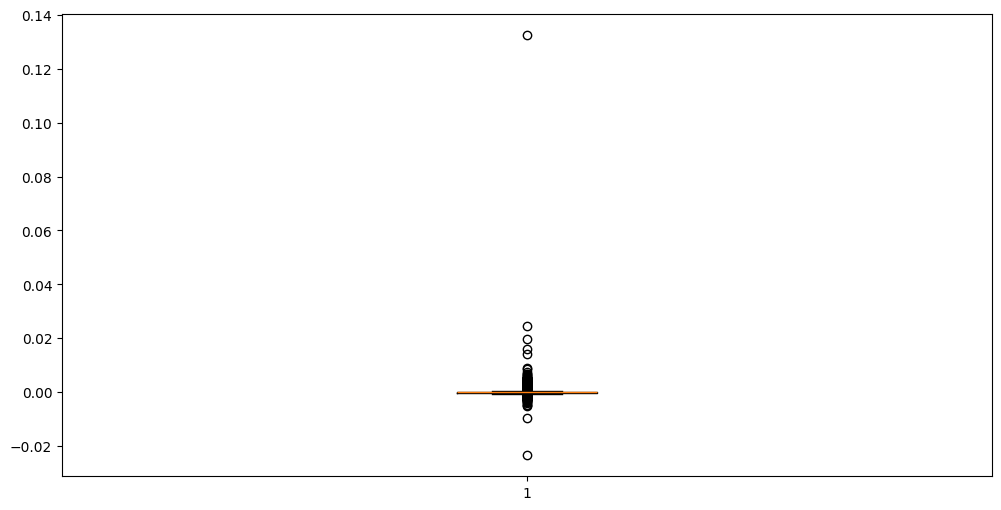

In [127]:
plt.figure(figsize=(12,6))
plt.boxplot(df["avg_atomic_charge_quadrupole_interaction"])
plt.show()

In [ ]:
df.iloc[8169]["smiles"]

'[C:1](#[C:2][H:4])[H:3]'

In [38]:


from scipy.stats import ttest_rel

ttest_result = ttest_rel(scores_combo["test_r2"], scores_topo["test_r2"])
print(f"p-value: {ttest_result[1]} -> not statistically significant")

print("Topo mean R2:", scores_topo["test_r2"].mean())
print("Combined mean R2:", scores_combo["test_r2"].mean())
print("Mean improvement:", (scores_combo["test_r2"] - scores_topo["test_r2"]).mean())

p-value: 0.32728160050511285 -> not statistically significant
Topo mean R2: 0.8100948653312997
Combined mean R2: -68715.20450089981
Mean improvement: -68716.01459576514


In [42]:
print(f"Train MSE scores:\nTopology alone: {np.abs(scores_topo["train_MSE"]).mean()}\nQM alone: {np.abs(scores_qm["train_MSE"]).mean()}\nCombined: {np.abs(scores_combo["train_MSE"]).mean()}")
print("\n")
print(f"Test MSE scores:\nTopology alone: {np.abs(scores_topo["test_MSE"]).mean()}\nQM alone: {np.abs(scores_qm["test_MSE"]).mean()}\nCombined: {np.abs(scores_combo["test_MSE"]).mean()}")

Train MSE scores:
Topology alone: 0.9090476273849084
QM alone: 1.3084775325071598
Combined: 0.8282868009887798


Test MSE scores:
Topology alone: 0.9707238587867568
QM alone: 1.3950777881496885
Combined: 0.957075503017653


In [58]:
ttest_result = ttest_rel(np.abs(scores_combo["test_MSE"]), np.abs(scores_topo["test_MSE"]))

print("Topo mean R2:", np.abs(scores_topo["test_MSE"]).mean())
print("Combined mean R2:", np.abs(scores_combo["test_MSE"]).mean())
print("Mean improvement:", (np.abs(scores_combo["test_MSE"]) - np.abs(scores_topo["test_MSE"])).mean())
print(f"p-value: {ttest_result[1]} -> not statistically significant")

Topo mean R2: 0.9707238587867568
Combined mean R2: 0.957075503017653
Mean improvement: -0.013648355769103726
p-value: 0.6735392490799408 -> not statistically significant


For the linear regression, the QM descriptors alone seem to give the worst performance out of the three, but **there seems to be no significant difference between the topological descriptors alone and the combined feature set**. This can mean three things, the QM descriptors provide no advantage because:
- due to the larger dataset (desired outcome)
- They are not so useful for solubility predictions
- The linear model cannot benefit from using them (in one way or another) 

## Recursive Feature Elimination

Lets try and make a RFE to see whether the QM descriptors do in fact provide any value to the linear model.

In [ ]:
rfe_pipe = make_pipeline(RFECV(LinearRegression(), cv=cv, scoring="r2", n_jobs=4), "rfe")
rfe_pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance', ...), ('remove_corr', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,threshold,0.95
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",False
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


In [15]:
filtered_features = rfe_pipe.get_feature_names_out()
X_rfe = X[filtered_features]
X_rfe.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Columns: 224 entries, energy to fr_unbrch_alkane
dtypes: float64(143), int64(81)
memory usage: 15.0 MB


In these remaining features, I am curious how many QM features are still left. 

In [ ]:
with open("../data/properties.json", "r") as f:
    data = json.load(f)

qm_feature_names = [feature["name_of_property"] for feature in data]

In [ ]:
scores_pre_rfe = cross_validate(pl_linear, X, y, cv=repeated_cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [ ]:
scores_post_rfe = cross_validate(pl_linear, X_rfe, y, cv=repeated_cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [ ]:
train_score_pre_rfe = scores_pre_rfe["train_r2"].mean()
test_score_pre_rfe = scores_pre_rfe["test_r2"].mean()
print(f"Pre-RFE:\nTrain score : {train_score_pre_rfe}\nTest score: {test_score_pre_rfe}\nDifference: {abs(test_score_pre_rfe - train_score_pre_rfe)}")

print("\n")

train_score_rfe = scores_post_rfe['train_r2'].mean()
test_score_rfe = scores_post_rfe['test_r2'].mean()
print(f"Post-RFE:\nTrain score : {train_score_rfe}\nTest score: {test_score_rfe}\nDifference: {abs(test_score_rfe - train_score_rfe)}")

Pre-RFE:
Train score : 0.8444746051286064
Test score: 0.819930810419778
Difference: 0.024543794708828393


Post-RFE:
Train score : 0.844194812217097
Test score: 0.8236274876806462
Difference: 0.020567324536450826


The difference between the test and train score is for both situations small => no overfitting

In [ ]:
print(f"Pre-RFE R2 score: {scores_pre_rfe['test_r2'].mean()}\nPost-RFE R2 score: {scores_post_rfe['test_r2'].mean()}\nMean improvement: {(scores_post_rfe['test_r2'] - scores_pre_rfe['test_r2']).mean()}")
p_value = ttest_rel(scores_pre_rfe['test_r2'], scores_post_rfe['test_r2'])[1]
print(f"p-value: {p_value}")

Pre-RFE R2 score: 0.819930810419778
Post-RFE R2 score: 0.8236274876806462
Mean improvement: 0.0036966772608682643
p-value: 0.02099587838264687


Despite the fact that the mean improvement of $R^2$ is so small, the increase is statistically significant. By reducing the amount of features with the RFE, we got an increase in performance.

In [26]:
def get_best_pl(fit):
    return fit["estimator"][fit["test_r2"].argmax()]    

In [ ]:
best_post_rfe_pl = get_best_pl(scores_post_rfe)
best_pre_rfe_pl = get_best_pl(scores_pre_rfe)

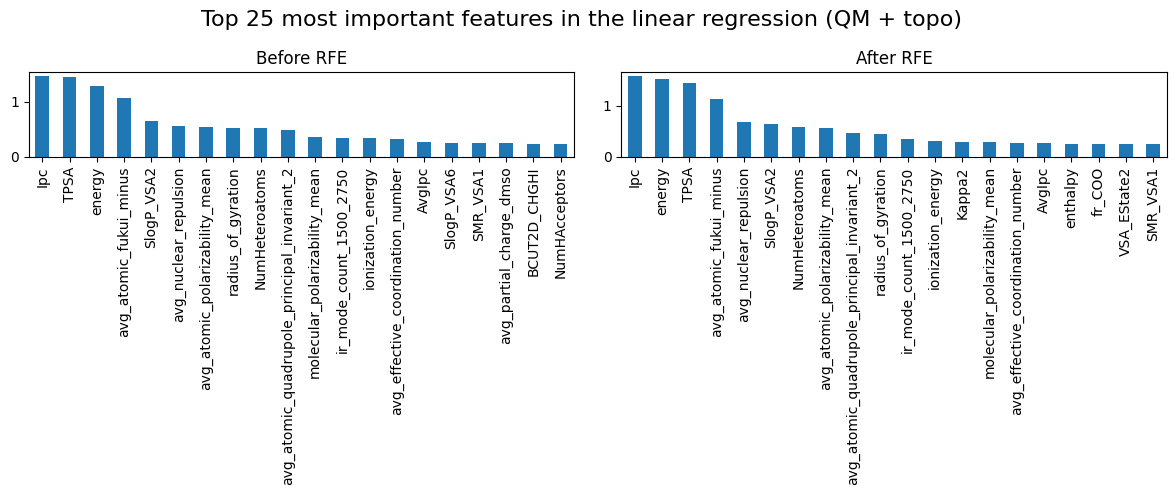

In [ ]:
pre_rfe_importance = pd.Series(
    best_pre_rfe_pl.named_steps["predict"].coef_,
    index=best_pre_rfe_pl[:-1].get_feature_names_out()
    )

post_rfe_importance = pd.Series(
    best_post_rfe_pl.named_steps["predict"].coef_,
    index=best_post_rfe_pl[:-1].get_feature_names_out()
    )

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

pre_rfe_importance.abs().sort_values(ascending=False)[:20].plot.bar(ax=ax[0])
ax[0].set_title("Before RFE")

post_rfe_importance.abs().sort_values(ascending=False)[:20].plot.bar(ax=ax[1])
ax[1].set_title("After RFE")

plt.suptitle("Top 25 most important features in the linear regression (QM + topo)", fontsize=16)
plt.tight_layout()
plt.show()

In [21]:
qm_remaining_features = X_rfe.columns[X_rfe.columns.isin(qm_feature_names)]
print(len(qm_remaining_features))
post_rfe_importance[qm_remaining_features]

14


energy                                       -1.531946
homo_lumo_gap                                -0.121599
ionization_energy                            -0.307517
electron_affinity                            -0.122518
chemical_potential                           -0.014554
molecular_dipole_norm                         0.133269
molecular_quadrupole_principal_invariant_2   -0.019968
molecular_polarizability_mean                 0.286234
molecular_polarizability_anisotropy           0.029257
enthalpy                                     -0.257311
radius_of_gyration                           -0.448713
sterimol_Bmin                                 0.020693
sterimol_Bmax                                 0.035902
solvation_energy_water                       -0.012800
dtype: float64

In [22]:
len(qm_remaining_features)

14

In [23]:
tot_cols = len(X_rfe.columns)
fr_cols = len(X_rfe.filter(regex="fr_").columns)
qm_cols = len(qm_remaining_features)
print(f"Fraction of 'fr_' features remaining in the dataset: {fr_cols / tot_cols}")
print(f"Fraction of QM features remaining in the dataset: {qm_cols / tot_cols}")

Fraction of 'fr_' features remaining in the dataset: 0.28125
Fraction of QM features remaining in the dataset: 0.0625
